In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
df = pd.read_csv("Harman.8.csv")
df.head()

,rownames,Height,Arm span,Forearm,Leg length,Weight,Hips,Chest girth,Chest width
0,Height,1.000,0.846,0.805,0.859,0.473,0.398,0.301,0.382
1,Arm span,0.846,1.000,0.881,0.826,0.376,0.326,0.277,0.415
2,Length of forearm,0.805,0.881,1.000,0.801,0.380,0.319,0.237,0.345
3,Length of lower leg,0.859,0.826,0.801,1.000,0.436,0.329,0.327,0.365
4,Weight,0.473,0.376,0.380,0.436,1.000,0.762,0.730,0.629


In [4]:
df.shape

(8, 9)

In [5]:
df = df.set_index("rownames")
df.head()

,Height,Arm span,Forearm,Leg length,Weight,Hips,Chest girth,Chest width
rownames,,,,,,,,
Height,1.000,0.846,0.805,0.859,0.473,0.398,0.301,0.382
Arm span,0.846,1.000,0.881,0.826,0.376,0.326,0.277,0.415
Length of forearm,0.805,0.881,1.000,0.801,0.380,0.319,0.237,0.345
Length of lower leg,0.859,0.826,0.801,1.000,0.436,0.329,0.327,0.365
Weight,0.473,0.376,0.380,0.436,1.000,0.762,0.730,0.629


In [6]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

chi_square_value, p_value = calculate_bartlett_sphericity(df)
kmo_all, kmo_model = calculate_kmo(df)

print("Bartlett’s test p-value:", p_value)
print("KMO overall:", kmo_model)

# Bartlett p < 0.05 → correlations exist 
# KMO > 0.6 → FA is appropriate 

Bartlett’s test p-value: 9.026967779128914e-23
KMO overall: 0.8471961803471197


/home/tako/Kasetsart/statistics/.devenv/state/venv/lib/python3.13/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


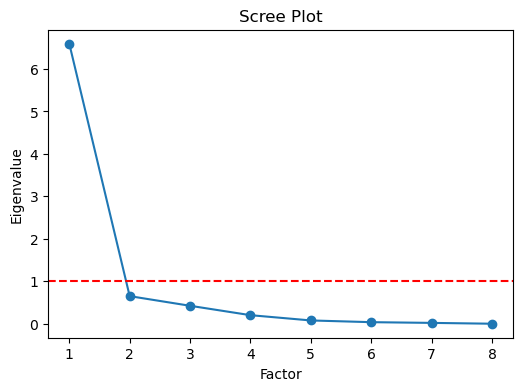

In [7]:
# Determine number of factors (Eigenvalues)
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt

fa = FactorAnalyzer(rotation=None)
fa.fit(df)

eigenvalues, _ = fa.get_eigenvalues()

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.axhline(y=1, color='red', linestyle='--')
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.show()

#Kaiser criterion → eigenvalue > 1
#Scree “elbow” → typical solution ≈ 3–5 factors

In [9]:
# Run Factor Analysis: Least Squares (default) (with rotation)
selected_n_factors = 5   # can be adjusted
fa = FactorAnalyzer(n_factors=selected_n_factors, method="minres", rotation='varimax')  # other options for method are 'principal' and 'ml'
fa.fit(df)

factor_columns = []
for i in range(1,selected_n_factors+1):
    factor_columns.append("Factor"+str(i))

loadings = pd.DataFrame(
    fa.loadings_,
    index=df.columns,
    columns=factor_columns
)

print(loadings.round(2))

             Factor1  Factor2  Factor3  Factor4  Factor5
Height          0.72     0.43     0.48    -0.11     0.17
Arm span        0.70     0.52     0.38    -0.25    -0.01
Forearm         0.71     0.48     0.45    -0.22    -0.14
Leg length      0.64     0.53     0.49    -0.14     0.17
Weight         -0.50    -0.52    -0.23     0.65    -0.01
Hips           -0.33    -0.88    -0.22     0.24    -0.01
Chest girth    -0.91    -0.23    -0.16     0.29     0.01
Chest width    -0.24    -0.19    -0.94     0.13     0.00


/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


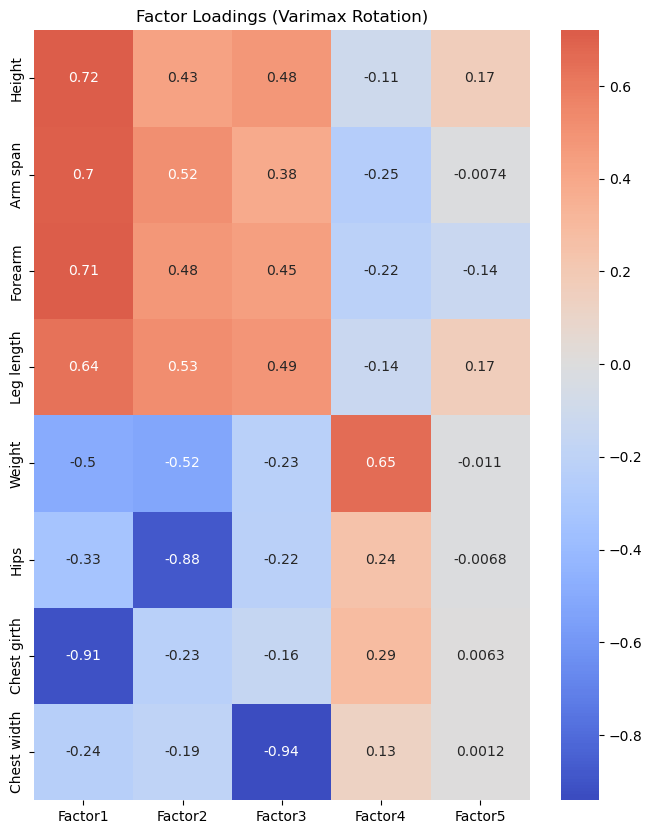

In [10]:
# Interpret factor loadings
plt.figure(figsize=(8,10))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("Factor Loadings (Varimax Rotation)")
plt.show()

# High loading (>|0.4|) → variable belongs to factor
# Factors represent latent abilities (e.g. verbal, spatial, memory)

In [11]:
# Communalities & variance explained
communalities = pd.Series(fa.get_communalities(), index=df.columns)
variance = pd.DataFrame(
    fa.get_factor_variance(),
    index=["SS Loadings", "Proportion Var", "Cumulative Var"],
    columns=factor_columns
)

print("Communalities:")
print(communalities.round(2))

print("\nVariance explained:")
print(variance.round(3))

# Communality → how much variance of a variable is explained
# Cumulative variance → how much total variance factors explain

Communalities:
Height         0.97
Arm span       0.97
Forearm        1.00
Leg length     0.96
Weight         1.00
Hips           1.00
Chest girth    1.00
Chest width    1.00
dtype: float64

Variance explained:
                Factor1  Factor2  Factor3  Factor4  Factor5
SS Loadings       3.169    2.095    1.825    0.725    0.075
Proportion Var    0.396    0.262    0.228    0.091    0.009
Cumulative Var    0.396    0.658    0.886    0.977    0.986


In [13]:
# Compute Factor Scores

# Get factor scores for each observation
factor_scores = fa.transform(df)  # shape: (n_samples, n_factors)

factor_scores_df = pd.DataFrame(factor_scores, columns=factor_columns)
print(factor_scores_df)

    Factor1   Factor2   Factor3   Factor4   Factor5
0  0.782112  0.282210  0.543733  0.043235  0.646009
1  0.800559  0.728341  0.328618 -0.218589  1.939291
2  0.640318  0.463764  0.569581 -0.642849 -2.874565
3  0.406622  0.646428  0.603699 -0.158965  1.130695
4 -0.118072 -0.366581 -0.073209  2.501124 -0.519231
5  0.053809 -2.475225  0.194388 -0.597385  0.964301
6 -2.476331  0.530725  0.457516 -0.267508  0.503075
7  0.043156  0.306467 -2.571632 -0.366334 -0.023180


/nix/store/8fk44f44pb38da87ifkkmdm9c2i977vh-devenv-profile/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
